# Prática: Problema do Caixeiro Chinês

## Objetivo
Implementar e testar um algoritmo para a solução ótima do problema do Caixeiro Chinês.

## Estrutura do Trabalho

### 1. Implementação do Algoritmo
- Desenvolver um algoritmo para a solução ótima do problema do Caixeiro Chinês.
- O código deve ser bem comentado, destacando:
  - Implementação do algoritmo de caminho mínimo
  - Implementação do emparelhamento
  - Implementação dos testes

### 2. Testes do Algoritmo
O algoritmo deve ser testado em 5 instâncias:
- **I.** Instância apresentada em aula (para testar a corretude da implementação)
- **II.** 4 instâncias apresentadas no AVA, contendo as distâncias entre pares de cidades

### Observações
- Pode-se utilizar as linguagens: Java, C, C++ ou Python

## Entregas
- Relatório via Moodle contendo:
  - Percurso encontrado em cada instância
  - Explicação da solução para a seleção dos emparelhamentos
- Código fonte comentado via Moodle, destacando as implementações mencionadas acima

## Parte I: Teste com Instância Apresentada em Aula

Nesta seção, será implementado e testado o algoritmo para o problema do Caixeiro Chinês utilizando a biblioteca NetworkX, com uma instância simples para validar a corretude da solução.

In [91]:
import networkx as nx
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
import os

# Define explicitamente o diretório de saída para salvar tudo em 'pratica02/relatorio/resultado'
output_dir = os.path.abspath(os.path.join(os.getcwd(), '..', 'relatorio', 'resultado'))

def plotar_grafo(lista_adjacencia, titulo='Grafo', pos=None, nome_fig=None, mostrar_caminho=False):
    """
    Recebe uma lista de adjacência e plota o grafo correspondente.
    Parâmetro opcional 'pos' para definir as posições dos vértices.
    Se nome_fig for fornecido, salva a figura no diretório de resultados.
    Se mostrar_caminho=True, exibe o caminho do arquivo salvo.
    """
    import networkx as nx
    import matplotlib.pyplot as plt
    G = nx.Graph()
    for u, v, peso in lista_adjacencia:
        G.add_edge(u, v, weight=peso)
    if pos is None:
        pos = nx.spring_layout(G, seed=42)
    labels = nx.get_edge_attributes(G, 'weight')
    plt.figure(figsize=(8,5))
    nx.draw(G, pos, with_labels=True, node_color='lightblue', edge_color='gray', node_size=700, font_size=12)
    nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)
    plt.title(titulo)
    if nome_fig is not None:
        os.makedirs(output_dir, exist_ok=True)
        caminho_fig = os.path.join(output_dir, nome_fig)
        plt.savefig(caminho_fig, bbox_inches='tight', dpi=150)
        if mostrar_caminho:
            print(f'Arquivo salvo em: {caminho_fig}')
    plt.show()

def plotar_circuito(G, circuito, titulo='Circuito Euleriano Colorido', pos=None, nome_fig=None, mostrar_caminho=False):
    """
    Plota o grafo e destaca o circuito euleriano com cor diferente.
    Se nome_fig for fornecido, salva a figura no diretório de resultados.
    Se mostrar_caminho=True, exibe o caminho do arquivo salvo.
    """
    if pos is None:
        pos = nx.spring_layout(G, seed=42)

    # Todas as arestas do grafo
    edge_colors = []
    circuito_edges = set((min(u,v), max(u,v)) for u,v in circuito)
    for u, v in G.edges():
        if (min(u,v), max(u,v)) in circuito_edges:
            edge_colors.append('red')
        else:
            edge_colors.append('gray')
    
    labels = nx.get_edge_attributes(G, 'weight')
    plt.figure(figsize=(8,5))
    nx.draw(G, pos, with_labels=True, node_color='lightblue', edge_color=edge_colors, node_size=700, font_size=12, width=2)
    nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)
    plt.title(titulo)
    if nome_fig is not None:
        os.makedirs(output_dir, exist_ok=True)
        caminho_fig = os.path.join(output_dir, nome_fig)
        plt.savefig(caminho_fig, bbox_inches='tight', dpi=150)
        if mostrar_caminho:
            print(f'Arquivo salvo em: {caminho_fig}')
    plt.show()

def plotar_circuito_sem_sobreposicao(G, circuito, titulo='Circuito Euleriano Colorido', pos=None, nome_fig=None, mostrar_caminho=False):
    """
    Plota o grafo e destaca o circuito euleriano com cor diferente.
    Arestas duplicadas são desenhadas como curvas (meia-côncavas) para não sobrepor as originais.
    Se nome_fig for fornecido, salva a figura no diretório de resultados.
    Se mostrar_caminho=True, exibe o caminho do arquivo salvo.
    Enumera as arestas do circuito na ordem do percurso, inclusive as duplicadas, mantendo o peso visível.
    """
    import matplotlib.pyplot as plt
    import networkx as nx
    
    if pos is None:
        pos = nx.spring_layout(G, seed=42)
    
    # G deve ser MultiGraph para permitir arestas duplicadas
    if not isinstance(G, nx.MultiGraph):
        G = nx.MultiGraph(G)
    
    # Organiza as arestas do grafo por quantidade de duplicidade
    edge_count = {}
    for u, v, k in G.edges(keys=True):
        edge = tuple(sorted([u, v]))
        edge_count[edge] = edge_count.get(edge, 0) + 1
    
    plt.figure(figsize=(10,8))
    ax = plt.gca()
    ax.set_frame_on(False)  # Remove a borda ao redor do grafo
    nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=700)
    nx.draw_networkx_labels(G, pos, font_size=12)
    
    # Desenha arestas normais (não duplicadas)
    normal_edges = []
    for u, v, k in G.edges(keys=True):
        edge = tuple(sorted([u, v]))
        if edge_count[edge] == 1:
            normal_edges.append((u, v))
    nx.draw_networkx_edges(G, pos, edgelist=normal_edges, edge_color='gray', width=2)
    
    # Desenha arestas do circuito (duplicadas e não duplicadas) e enumera todas
    edge_passagem = {}
    for idx, (u, v) in enumerate(circuito):
        edge = tuple(sorted([u, v]))
        if edge_count[edge] > 1:
            rad = 0.2 + 0.15 * (edge_passagem.get(edge, 0))  # Curvatura diferente para cada duplicada
            nx.draw_networkx_edges(G, pos, edgelist=[(u, v)], edge_color='red', width=2, connectionstyle=f'arc3,rad={rad}')
        else:
            nx.draw_networkx_edges(G, pos, edgelist=[(u, v)], edge_color='red', width=2)
        # Enumera a aresta do circuito, inclusive duplicadas
        x = (pos[u][0] + pos[v][0]) / 2
        y = (pos[u][1] + pos[v][1]) / 2
        # Para duplicadas, alterna o deslocamento para cima/baixo e lateral
        if edge_count[edge] > 1:
            deslocamento_x = 0.25 * ((edge_passagem.get(edge, 0) % 2) * 2 - 1)  # alterna esquerda/direita
            deslocamento_y = -0.35 + 0.18 * (edge_passagem.get(edge, 0) // 2)  # alterna para cima/baixo
            plt.text(x + deslocamento_x, y + deslocamento_y, str(idx+1), color='blue', fontsize=8, fontweight='bold', bbox=dict(facecolor='white', edgecolor='none', alpha=0.5))
        else:
            plt.text(x, y-0.35, str(idx+1), color='blue', fontsize=8, fontweight='bold', bbox=dict(facecolor='white', edgecolor='none', alpha=0.5))
        edge_passagem[edge] = edge_passagem.get(edge, 0) + 1
    
    labels = nx.get_edge_attributes(G, 'weight')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)
    plt.title(titulo)
    if nome_fig is not None:
        os.makedirs(output_dir, exist_ok=True)
        caminho_fig = os.path.join(output_dir, nome_fig)
        plt.savefig(caminho_fig, bbox_inches='tight', dpi=150)
        if mostrar_caminho:
            print(f'Arquivo salvo em: {caminho_fig}')
    plt.show()

def caixeiro_chines(lista_adjacencia):
    """
    Recebe uma lista de adjacência no formato:
    [ ('A', 'B', 2), ('A', 'C', 3), ... ]
    Retorna o circuito euleriano encontrado e o grafo eulerizado.
    """
    G = nx.Graph()
    for u, v, peso in lista_adjacencia:
        G.add_edge(u, v, weight=peso)
    
    # Euleriza o grafo se necessário
    G_euler = nx.eulerize(G)
    
    # Encontra o circuito euleriano
    circuito = list(nx.eulerian_circuit(G_euler))
    return circuito, G_euler

def tabela_percurso(circuito, G_euler, nome_csv='percurso.csv', mostrar_caminho=False):
    dados = []
    for u, v in circuito:
        # Busca robusta do peso para MultiGraph e Graph
        peso = '-'
        if isinstance(G_euler, nx.MultiGraph):
            # MultiGraph: pode haver múltiplas arestas, pega o primeiro peso disponível
            edge_data = G_euler.get_edge_data(u, v)
            if edge_data:
                # edge_data é um dict de dicts: {0: {...}, 1: {...}, ...}
                for k in edge_data:
                    if 'weight' in edge_data[k]:
                        peso = edge_data[k]['weight']
                        break
        else:
            # Graph: acesso direto
            if G_euler.has_edge(u, v):
                peso = G_euler[u][v].get('weight', '-')
        dados.append({'Origem': u, 'Destino': v, 'Peso': peso})

    df = pd.DataFrame(dados)
    print(df)
    # Salvar CSV no diretório relatorio/resultado
    os.makedirs(output_dir, exist_ok=True)
    caminho_csv = os.path.join(output_dir, nome_csv)
    df.to_csv(caminho_csv, index=False, encoding='utf-8')
    if mostrar_caminho:
        print(f'Arquivo salvo em: {caminho_csv}')

# Para MultiGraph, pega o peso da primeira aresta entre u e v
def mostrar_percurso(circuito, G_euler):
    print("Origem | Destino | Peso")
    for idx, (u, v) in enumerate(circuito):
        dados_arestas = G_euler.get_edge_data(u, v)
        if isinstance(dados_arestas, dict):
            # MultiGraph: pega o primeiro peso disponível
            if 0 in dados_arestas:
                peso = dados_arestas[0].get('weight', '-')
            else:
                # Caso não seja MultiGraph, pega direto
                peso = list(dados_arestas.values())[0].get('weight', '-')
        else:
            peso = '-'
        print(f"{idx+1:>3} | {u:>6} | {v:>7} | {peso:>4}")

def mostrar_info_grafo(G):
    print('--- Informações do Grafo ---')
    print(f'Nº de vértices: {G.number_of_nodes()}')
    print(f'Nº de arestas: {G.number_of_edges()}')
    print('Vértices:', list(G.nodes()))
    print('Arestas:', list(G.edges(data=True)))
    print('Graus dos vértices:')
    for n, d in G.degree():
        print(f'  {n}: grau {d}')
    print('Pesos das arestas:')
    for u, v, data in G.edges(data=True):
        print(f'  ({u}, {v}): {data.get("weight", None)}')
    print('Matriz de adjacência:')
    print(nx.to_numpy_array(G))
    print('É conexo?', nx.is_connected(G))
    print('É euleriano?', nx.is_eulerian(G))
    print('Componentes conexas:', list(nx.connected_components(G)))
    print('--- Fim das informações ---')


## Parte II: Teste com Instância Apresentada em Aula

A segunda parte do trabalho consiste no teste do algoritmo implementadoem5 instâncias:

### I - Instância apresentada em aula a fim de testar a corretude da implementação:

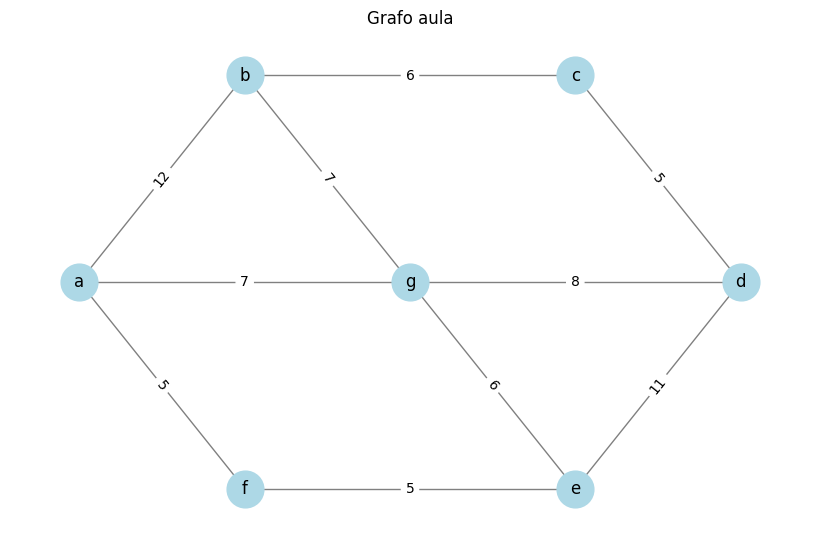

Origem | Destino | Peso
  1 |      a |       f |    5
  2 |      f |       e |    5
  3 |      e |       d |   11
  4 |      d |       e |   11
  5 |      e |       g |    6
  6 |      g |       d |    8
  7 |      d |       c |    5
  8 |      c |       b |    6
  9 |      b |       g |    7
 10 |      g |       a |    7
 11 |      a |       b |   12
 12 |      b |       a |   12


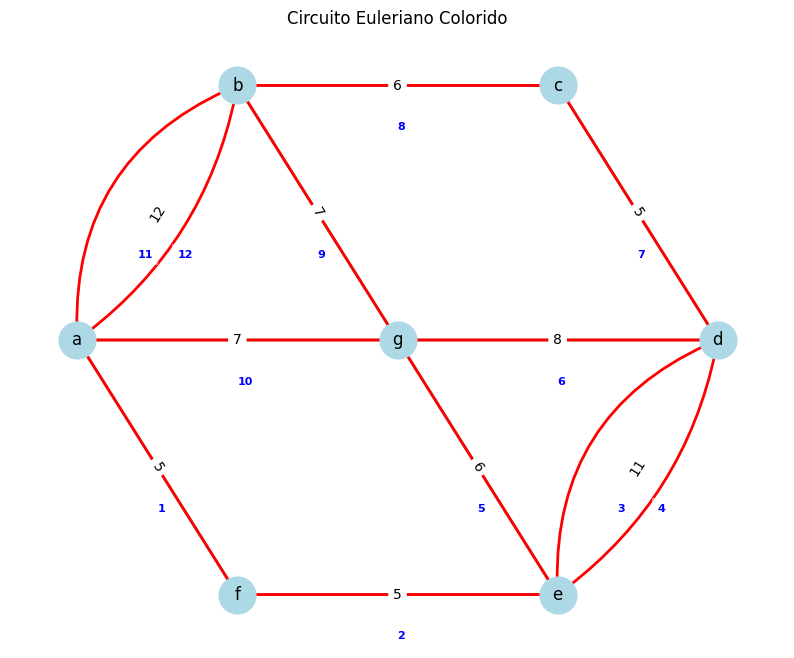

--- Informações do Grafo ---
Nº de vértices: 7
Nº de arestas: 12
Vértices: ['a', 'b', 'g', 'f', 'c', 'd', 'e']
Arestas: [('a', 'b', {'weight': 12}), ('a', 'b', {}), ('a', 'g', {'weight': 7}), ('a', 'f', {'weight': 5}), ('b', 'c', {'weight': 6}), ('b', 'g', {'weight': 7}), ('g', 'd', {'weight': 8}), ('g', 'e', {'weight': 6}), ('f', 'e', {'weight': 5}), ('c', 'd', {'weight': 5}), ('d', 'e', {'weight': 11}), ('d', 'e', {})]
Graus dos vértices:
  a: grau 4
  b: grau 4
  g: grau 4
  f: grau 2
  c: grau 2
  d: grau 4
  e: grau 4
Pesos das arestas:
  (a, b): 12
  (a, b): None
  (a, g): 7
  (a, f): 5
  (b, c): 6
  (b, g): 7
  (g, d): 8
  (g, e): 6
  (f, e): 5
  (c, d): 5
  (d, e): 11
  (d, e): None
Matriz de adjacência:
[[ 0. 13.  7.  5.  0.  0.  0.]
 [13.  0.  7.  0.  6.  0.  0.]
 [ 7.  7.  0.  0.  0.  8.  6.]
 [ 5.  0.  0.  0.  0.  0.  5.]
 [ 0.  6.  0.  0.  0.  5.  0.]
 [ 0.  0.  8.  0.  5.  0. 12.]
 [ 0.  0.  6.  5.  0. 12.  0.]]
É conexo? True
É euleriano? True
Componentes conexas: [{'b',

In [92]:
# Exemplo de uso
lista = [
    ('a', 'b', 12),
    ('a', 'g', 7),
    ('a', 'f', 5),
    ('b', 'c', 6),
    ('b', 'g', 7),
    ('c', 'd', 5),
    ('d', 'g', 8),
    ('d', 'e', 11),
    ('e', 'f', 5),
    ('e', 'g', 6),
]

pos = { 'a': (0,0), 
        'b': (2,2), 
        'c': (6,2), 
        'd': (8,0),
        'e': (6,-2),
        'f': (2,-2),
        'g': (4,0),
        }

plotar_grafo(lista, titulo='Grafo aula', pos=pos, nome_fig='grafo_aula.png')
circuito, G_euler = caixeiro_chines(lista)
mostrar_percurso(circuito, G_euler)
# Plota o circuito enumerando as arestas, sem sobrescrever os pesos
plotar_circuito_sem_sobreposicao(G_euler, circuito, titulo='Circuito Euleriano Colorido', pos=pos, nome_fig='circuito_euleriano_aula.png')
mostrar_info_grafo(G_euler)
tabela_percurso(circuito, G_euler, nome_csv='percurso_aula.csv')


### II.04 instâncias apresentadas no AVA contendo as distâncias entre pares de cidades;

Instância: gr15.tsp
Arquivo salvo em: d:\GitHub\DoutoradoCefet\TeoriaGrafos\praticas\pratica02\relatorio\resultado\grafo_gr15.tsp.png
Arquivo salvo em: d:\GitHub\DoutoradoCefet\TeoriaGrafos\praticas\pratica02\relatorio\resultado\grafo_gr15.tsp.png


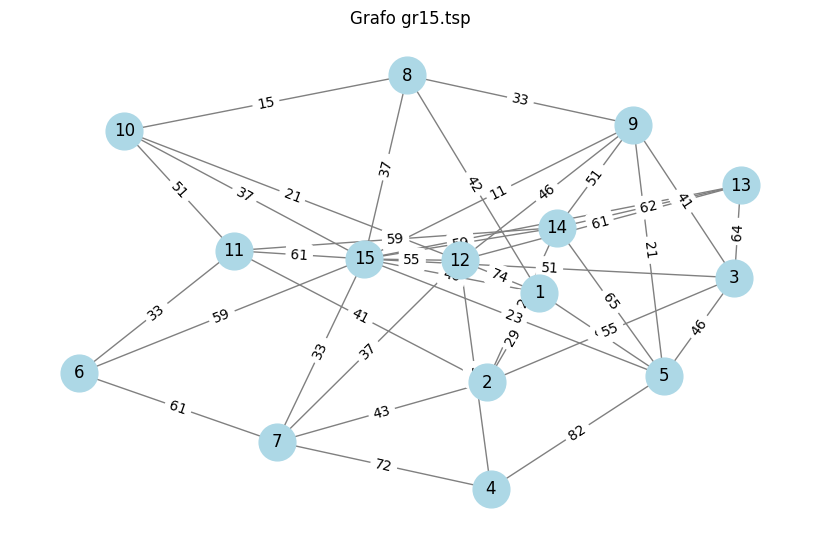

Arquivo salvo em: d:\GitHub\DoutoradoCefet\TeoriaGrafos\praticas\pratica02\relatorio\resultado\circuito_euleriano_gr15.tsp.png


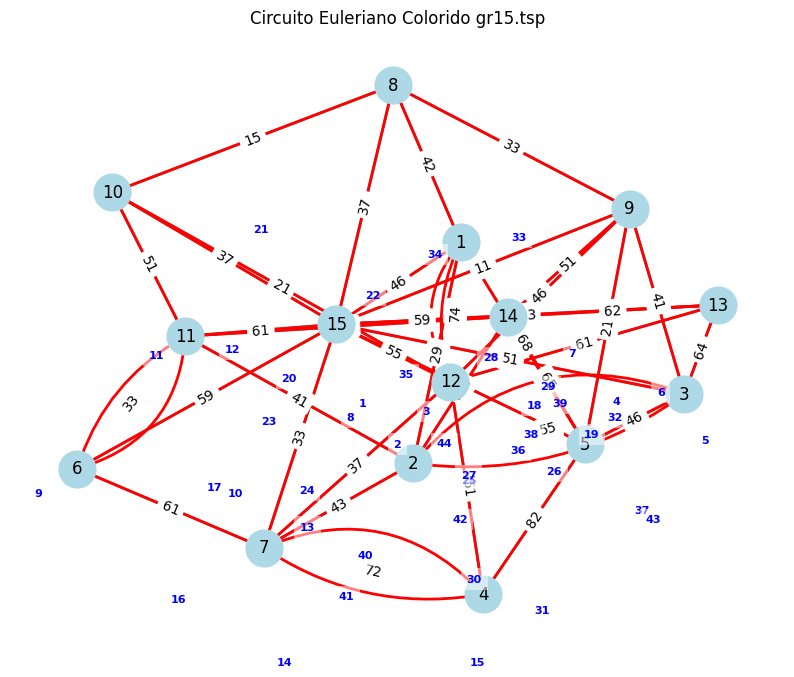

Origem | Destino | Peso
  1 |      1 |      12 |   74
  2 |     12 |      15 |   55
  3 |     15 |      14 |   59
  4 |     14 |      13 |   62
  5 |     13 |       3 |   64
  6 |      3 |       9 |   41
  7 |      9 |      14 |   51
  8 |     14 |      11 |   59
  9 |     11 |       6 |   33
 10 |      6 |      11 |   33
 11 |     11 |      10 |   51
 12 |     10 |      15 |   37
 13 |     15 |       7 |   33
 14 |      7 |       4 |   72
 15 |      4 |       7 |   72
 16 |      7 |       6 |   61
 17 |      6 |      15 |   59
 18 |     15 |      13 |   23
 19 |     13 |      12 |   61
 20 |     12 |      10 |   21
 21 |     10 |       8 |   15
 22 |      8 |      15 |   37
 23 |     15 |      11 |   61
 24 |     11 |       2 |   41
 25 |      2 |      14 |   52
 26 |     14 |       5 |   65
 27 |      5 |      15 |   23
 28 |     15 |       9 |   11
 29 |      9 |      12 |   46
 30 |     12 |       4 |   51
 31 |      4 |       5 |   82
 32 |      5 |       9 |   21
 33 |      9 |  

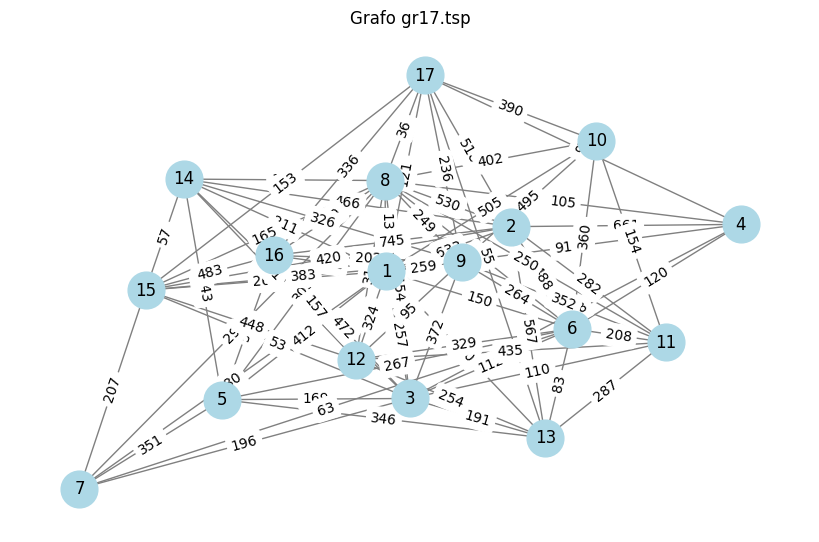

Arquivo salvo em: d:\GitHub\DoutoradoCefet\TeoriaGrafos\praticas\pratica02\relatorio\resultado\circuito_euleriano_gr17.tsp.png


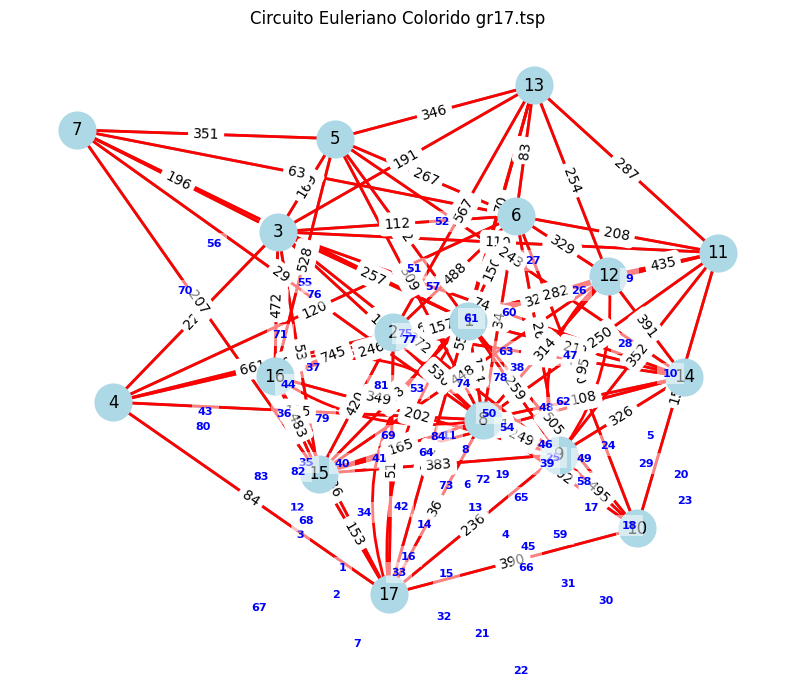

Origem | Destino | Peso
  1 |      1 |      17 |  121
  2 |     17 |      16 |  336
  3 |     16 |      15 |  483
  4 |     15 |      14 |   57
  5 |     14 |      12 |  391
  6 |     12 |      15 |  448
  7 |     15 |      17 |  153
  8 |     17 |      13 |   55
  9 |     13 |      11 |  287
 10 |     11 |      12 |  435
 11 |     12 |      16 |  157
 12 |     16 |       8 |  349
 13 |      8 |      16 |  349
 14 |     16 |       9 |  202
 15 |      9 |      15 |  383
 16 |     15 |       8 |  165
 17 |      8 |      14 |  108
 18 |     14 |       9 |  326
 19 |      9 |      12 |   95
 20 |     12 |       9 |   95
 21 |      9 |      17 |  236
 22 |     17 |      10 |  390
 23 |     10 |      11 |  154
 24 |     11 |       8 |  250
 25 |      8 |      12 |  314
 26 |     12 |      13 |  254
 27 |     13 |       6 |   83
 28 |      6 |      11 |  208
 29 |     11 |       9 |  352
 30 |      9 |      10 |  495
 31 |     10 |       8 |  402
 32 |      8 |      17 |   36
 33 |     17 |  

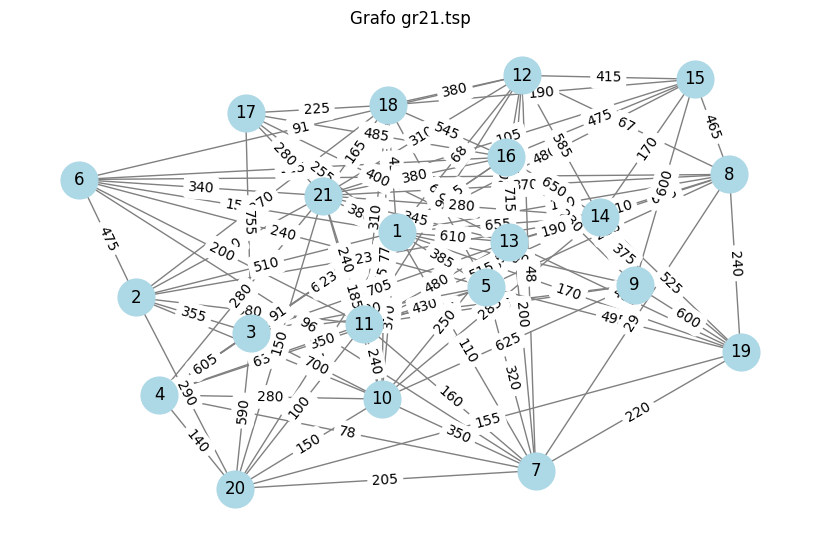

Arquivo salvo em: d:\GitHub\DoutoradoCefet\TeoriaGrafos\praticas\pratica02\relatorio\resultado\circuito_euleriano_gr21.tsp.png


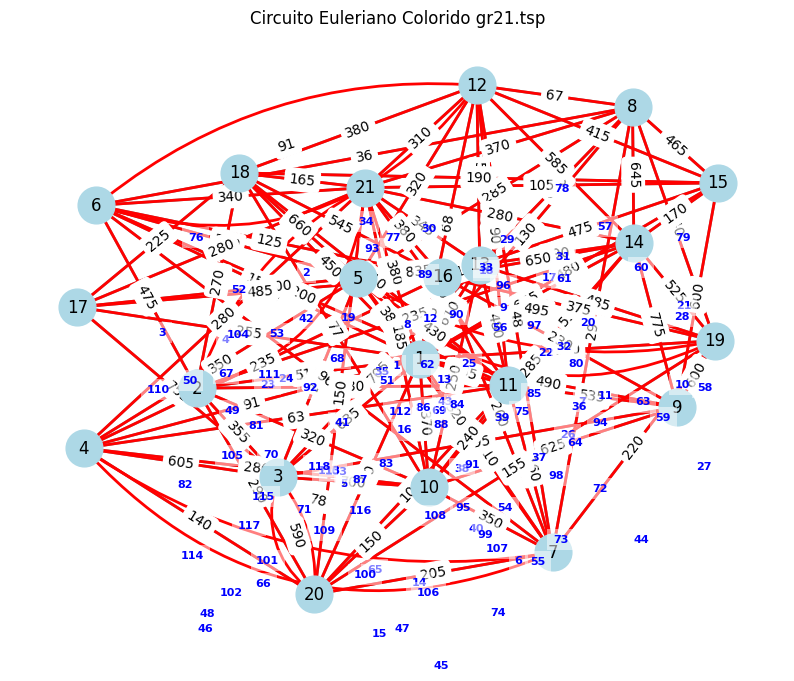

Origem | Destino | Peso
  1 |      1 |      21 |  380
  2 |     21 |      18 |  165
  3 |     18 |      17 |  225
  4 |     17 |      21 |  280
  5 |     21 |      20 |  150
  6 |     20 |      19 |  155
  7 |     19 |      16 |  375
  8 |     16 |      21 |  380
  9 |     21 |      14 |  280
 10 |     14 |      19 |  525
 11 |     19 |      13 |  485
 12 |     13 |      21 |  345
 13 |     21 |      11 |  240
 14 |     11 |      20 |  100
 15 |     20 |      10 |  150
 16 |     10 |      21 |  185
 17 |     21 |      15 |  105
 18 |     15 |      18 |  190
 19 |     18 |      16 |  545
 20 |     16 |      15 |  475
 21 |     15 |      14 |  170
 22 |     14 |      16 |  650
 23 |     16 |      17 |  485
 24 |     17 |      13 |  400
 25 |     13 |      16 |  715
 26 |     16 |       9 |  230
 27 |      9 |      19 |  600
 28 |     19 |       8 |  240
 29 |      8 |      21 |  370
 30 |     21 |      12 |  310
 31 |     12 |      14 |  585
 32 |     14 |      13 |  190
 33 |     13 |  

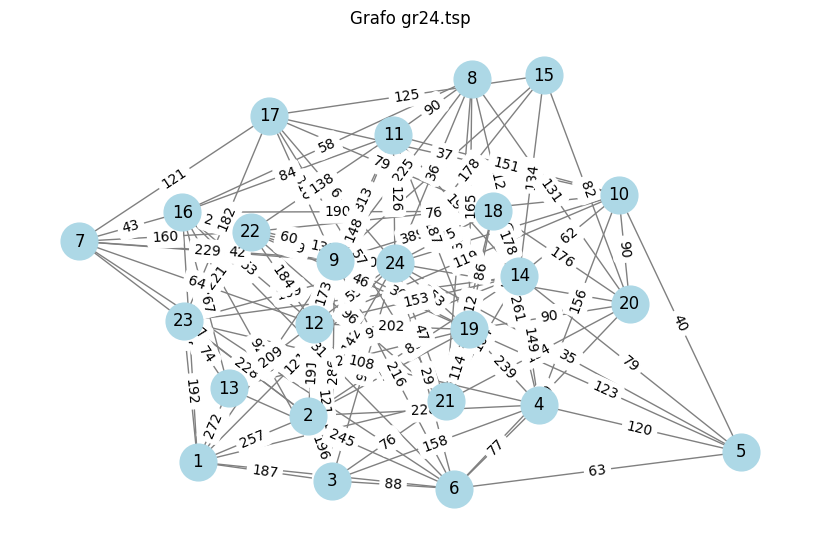

Arquivo salvo em: d:\GitHub\DoutoradoCefet\TeoriaGrafos\praticas\pratica02\relatorio\resultado\circuito_euleriano_gr24.tsp.png


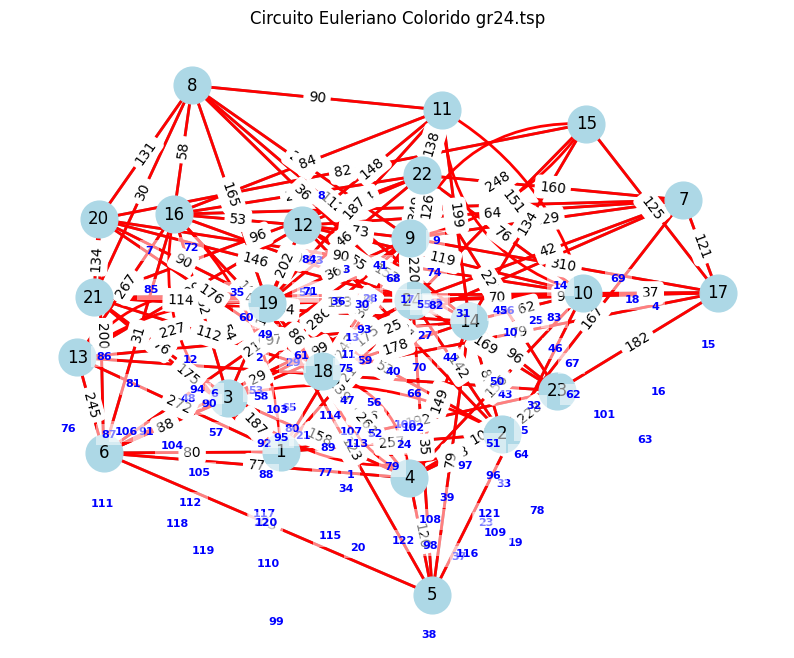

Origem | Destino | Peso
  1 |      1 |      24 |  121
  2 |     24 |      20 |  146
  3 |     20 |      15 |   82
  4 |     15 |      17 |  125
  5 |     17 |      18 |   79
  6 |     18 |      20 |  176
  7 |     20 |       8 |  131
  8 |      8 |      11 |   90
  9 |     11 |      22 |  138
 10 |     22 |      10 |   76
 11 |     10 |      20 |   90
 12 |     20 |      19 |   90
 13 |     19 |      22 |   46
 14 |     22 |       7 |  160
 15 |      7 |      17 |  121
 16 |     17 |      10 |   37
 17 |     10 |      11 |  151
 18 |     11 |      10 |  151
 19 |     10 |       5 |   40
 20 |      5 |      19 |  123
 21 |     19 |      18 |   86
 22 |     18 |       4 |  261
 23 |      4 |      18 |  261
 24 |     18 |      14 |  178
 25 |     14 |      15 |  134
 26 |     15 |      24 |  178
 27 |     24 |      22 |  135
 28 |     22 |      12 |  184
 29 |     12 |      19 |  202
 30 |     19 |      11 |  187
 31 |     11 |      14 |  199
 32 |     14 |      10 |   62
 33 |     10 |  

In [93]:
import re

def ler_tsp_lower_diag_row(filepath):
    with open(filepath, 'r') as f:
        lines = f.readlines()
    # Encontrar a linha EDGE_WEIGHT_SECTION
    start = None
    for i, line in enumerate(lines):
        if 'EDGE_WEIGHT_SECTION' in line:
            start = i + 1
            break
    if start is None:
        raise ValueError('EDGE_WEIGHT_SECTION não encontrada')
    # Extrair dimensão
    dim = None
    for line in lines:
        m = re.match(r'DIMENSION\s*:\s*(\d+)', line)
        if m:
            dim = int(m.group(1))
            break
    if dim is None:
        raise ValueError('DIMENSION não encontrada')
    # Ler matriz triangular inferior
    matriz = [[0]*dim for _ in range(dim)]
    idx = 0
    for i in range(dim):
        vals = []
        while len(vals) < i+1:
            vals += [int(x) for x in lines[start+idx].strip().split()]
            idx += 1
        for j in range(i+1):
            matriz[i][j] = vals[j]
            matriz[j][i] = vals[j]
    return matriz
def gerar_pos(lista):
    G_tmp = nx.Graph()
    for u, v, peso in lista:
        G_tmp.add_edge(u, v, weight=peso)
    pos = nx.spring_layout(G_tmp, seed=42)
    return pos

def matriz_para_lista_adjacencia(matriz):
    dim = len(matriz)
    lista = []
    for i in range(dim):
        for j in range(i+1, dim):
            if matriz[i][j] > 0:
                lista.append((str(i+1), str(j+1), matriz[i][j]))
    return lista

# Caminhos dos arquivos (corrigido)
arquivos = ['gr15.tsp', 'gr17.tsp', 'gr21.tsp', 'gr24.tsp']
for arquivo in arquivos:
    matriz = ler_tsp_lower_diag_row(f'../{arquivo}')
    lista = matriz_para_lista_adjacencia(matriz)
    print(f'Instância: {arquivo}')
 
    pos = gerar_pos(lista)  # Gera posições automáticas
    circuito, G_euler = caixeiro_chines(lista)
    plotar_grafo(lista, titulo=f'Grafo {arquivo}', nome_fig=f'grafo_{arquivo}.png', mostrar_caminho=True, pos=pos)
    plotar_circuito_sem_sobreposicao(G_euler, circuito, titulo=f'Circuito Euleriano Colorido {arquivo}', nome_fig=f'circuito_euleriano_{arquivo}.png', mostrar_caminho=True)
    mostrar_percurso(circuito, G_euler)
    tabela_percurso(circuito, G_euler, nome_csv=f'percurso_{arquivo}.csv')
